# [실습] 이변량분석(y-숫자)

* 카시트에 대해서 지역 매장 별 매출액을 예측하고자 한다.

# 1.환경준비

## 1.1. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as spst

## 1.2. 데이터 로딩

|	변수명	|	설명	|	구분	|
|	----	|	----	|	----	|
|	Sales 	|	 각 지역 판매량(단위 : 1000개)	|	Target	|
|	CompPrice 	|	지역별 경쟁사 판매가격(달러)	|	feature	|
|	Advertising 	|	 각 지역, 회사의 광고 예산(단위 : 1000달러)	|	feature	|
|	Population 	|	 지역 인구수(단위 : 1000명)	|	feature	|
|	Price 	|	 자사 지역별 판매가격(달러)	|	feature	|
|	ShelveLoc 	|	 진열상태	|	feature	|
|	Age 	|	 지역 인구의 평균 연령	|	feature	|
|	US 	|	 매장이 미국에 있는지 여부	|	feature	|
|	Income 	|	 지역 주민 평균 소득	|	feature	|
|	Urban 	|	 매장이 도시에 있는지 여부	|	feature	|



In [2]:
df = pd.read_csv('./data/Carseats.csv')
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Urban,US
0,9.50,138,73,11,276,120,Bad,42,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,Yes,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    str    
 7   Age          400 non-null    int64  
 8   Urban        400 non-null    str    
 9   US           400 non-null    str    
dtypes: float64(1), int64(6), str(3)
memory usage: 31.4 KB


In [4]:
target = 'Sales'



---



# 2.숫자형 X --> Y

* 모든 숫자형 X에 대해서 Y와 비교하여 차트를 그리고 수치화 하시오.

① 시각화 : scatter, jointplot  
② 수치화 : 상관분석

### 2.1. Advertising -> Sales

1) 시각화 : scatter(regplot), jointplot

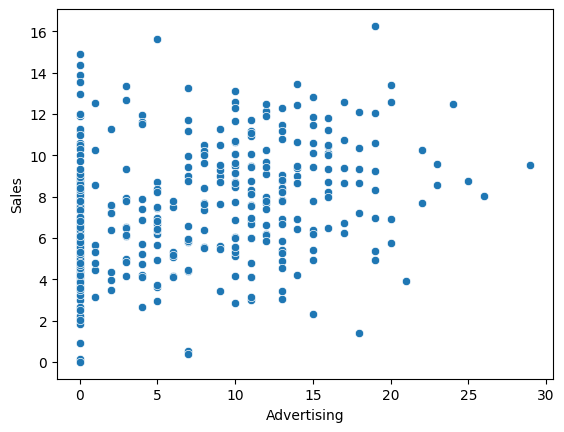

In [5]:
var = 'Advertising'

sns.scatterplot(x=var, y = target, data=df)
plt.show()

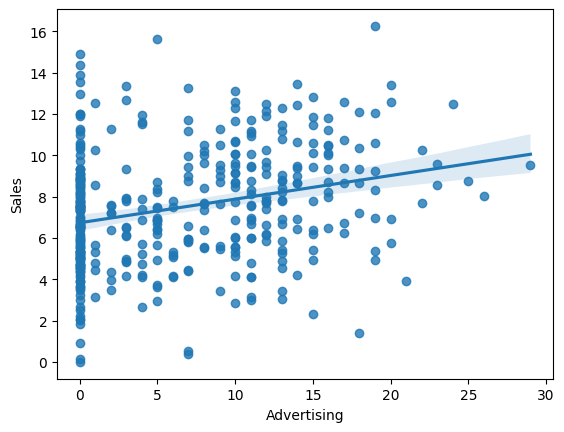

In [6]:
sns.regplot(x=var, y = target, data=df)
plt.show()

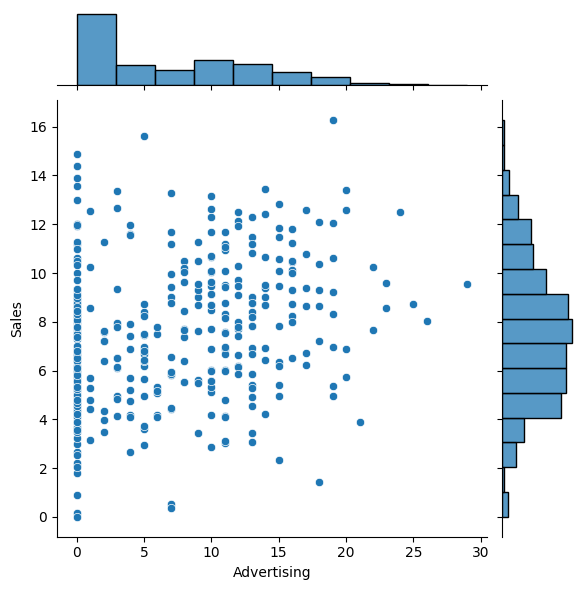

In [7]:
sns.jointplot(x=var, y = target, data=df)
plt.show()

2) 수치화 : 상관분석

In [8]:
result = spst.pearsonr(df[var], df[target])
print(f'상관계수 : {result[0]}, p-value : {result[1]}')

상관계수 : 0.269506781376902, p-value : 4.37767711030261e-08


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- 그래프로 볼땐, 희미하게 양의 상관관계가 보인다.
- 그런데, 상관분석을 수행해 보니, 관계가 있고, 상관 계수는 중간 정도의 관계를 보여준다.

[추가] 광고비 0 빼고 분석해보기

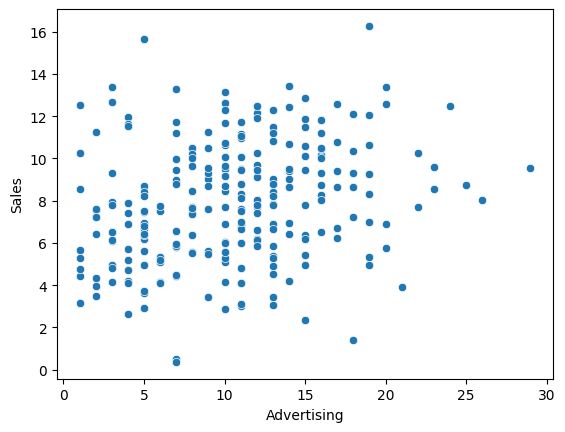

In [9]:
temp = df.loc[df[var] > 0]
sns.scatterplot(x=var, y = target, data = temp)
plt.show()

In [10]:
result = spst.pearsonr(temp[var], temp[target])
print(f'상관계수 : {result[0]}, p-value : {result[1]}')

상관계수 : 0.2571829256169392, p-value : 3.112672883086105e-05


### 2.2. Population -> Sales

1) 시각화 : scatter(regplot), jointplot

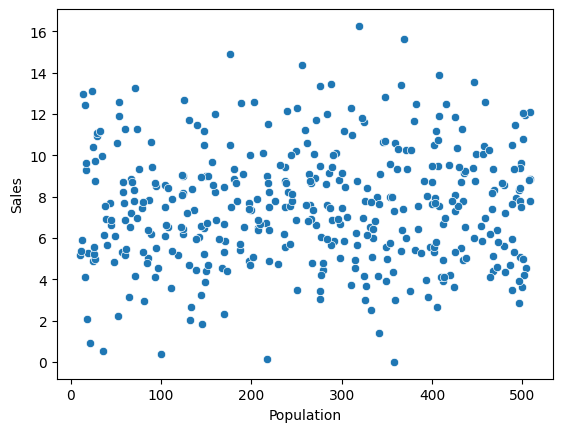

In [11]:
var = 'Population'

sns.scatterplot(x=var, y = target, data = df)
plt.show()

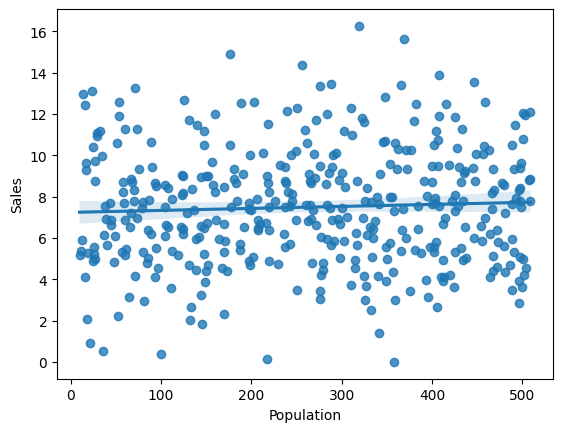

In [12]:
sns.regplot(x=var, y = target, data = df)
plt.show()

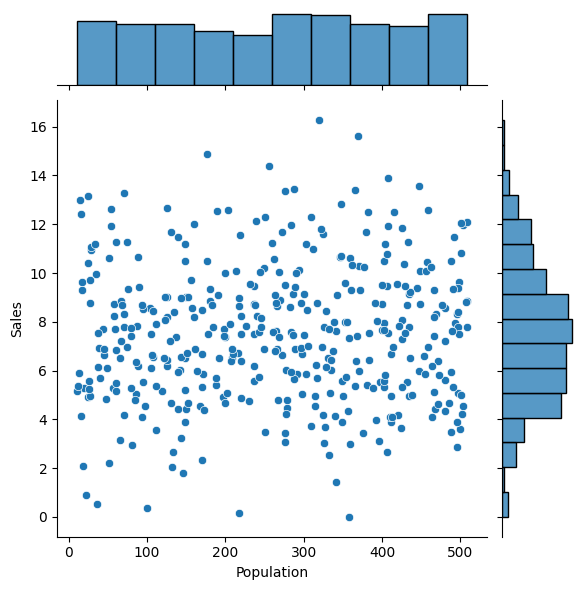

In [13]:
sns.jointplot(x=var, y = target, data = df)
plt.show()

2) 수치화 : 상관분석

In [14]:
result = spst.pearsonr(df[var], df[target])
print(f'상관계수 : {result[0]}, p-value : {result[1]}')

상관계수 : 0.05047098447203921, p-value : 0.3139816093190477


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- p value값이 0.05 이상이므로 상관 계수가 의미가 없다.
- 산점도 분포를 보아도 눈에 보이는 선형적 관계가 안보인다 그냥 난잡하게 분포되어 있다.

### 2.3. Price -> Sales

1) 시각화 : scatter(regplot), jointplot

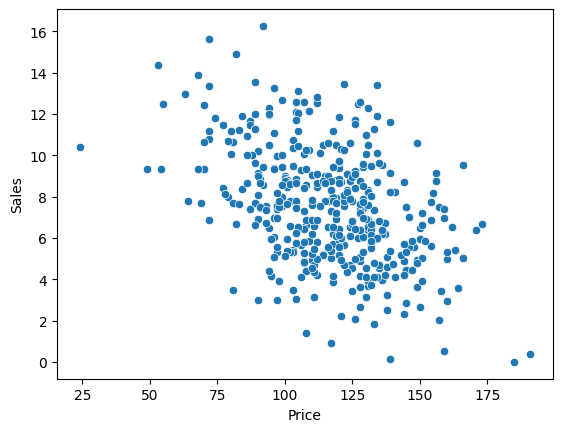

In [15]:
var = 'Price'

sns.scatterplot(x=var, y = target, data = df)
plt.show()

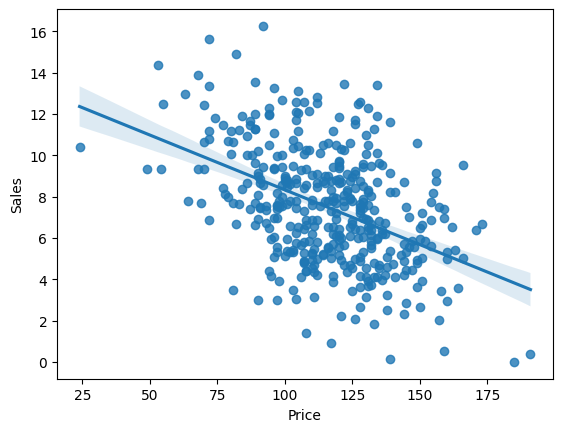

In [16]:
sns.regplot(x=var, y = target, data = df)
plt.show()

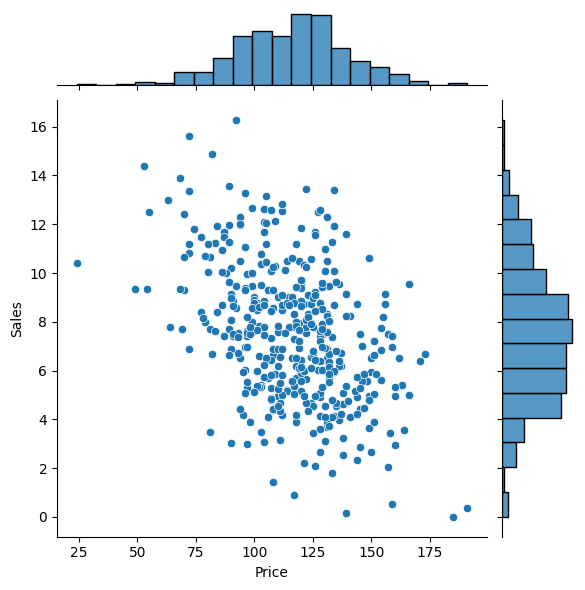

In [17]:
sns.jointplot(x=var, y = target, data = df)
plt.show()

2) 수치화 : 상관분석

In [18]:
result = spst.pearsonr(df[var], df[target])
print(f'상관계수 : {result[0]}, p-value : {result[1]}')

상관계수 : -0.44495072784657275, p-value : 7.618187011912755e-21


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- p value 값이 0.05 이하이므로 상관계수는 유의미 하다.
- 상관계수가 0.5보다 작으므로 중간정도의 상관 관계를 가진다

- 자사 가격과 판매량은 관련이 있다.(아주 강한것은 아님)

### 2.4. Age -> Sales

1) 시각화 : scatter(regplot), jointplot

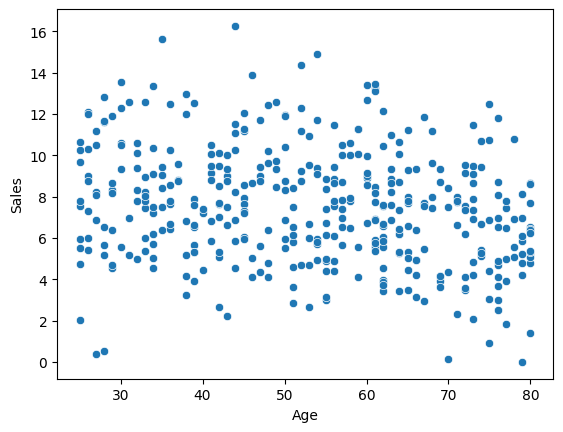

In [19]:
var = 'Age'

sns.scatterplot(x=var, y = target, data = df)
plt.show()

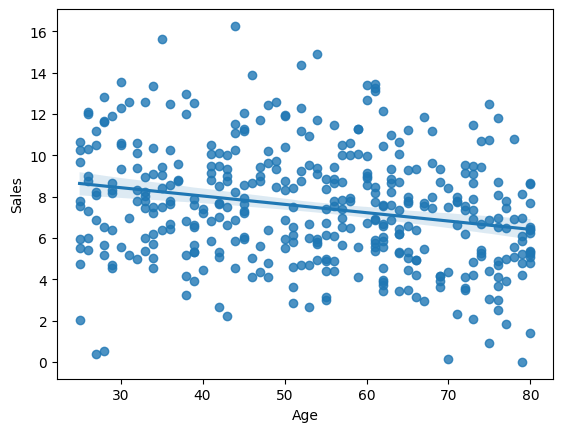

In [20]:
sns.regplot(x=var, y = target, data = df)
plt.show()

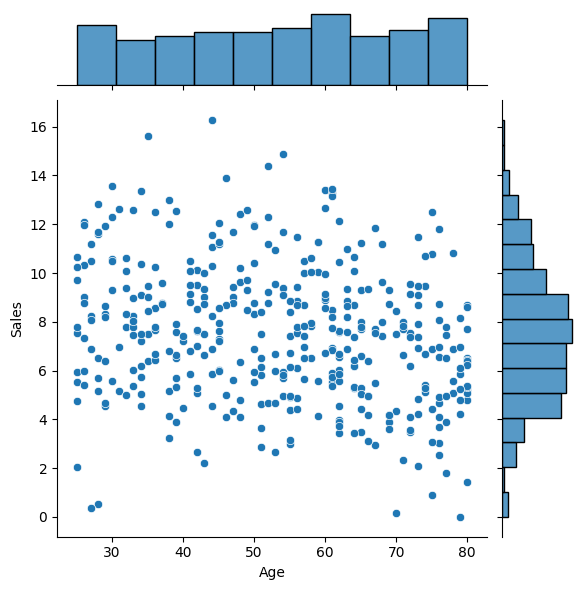

In [21]:
sns.jointplot(x=var, y = target, data = df)
plt.show()

2) 수치화 : 상관분석

In [22]:
result = spst.pearsonr(df[var], df[target])
print(f'상관계수 : {result[0]}, p-value : {result[1]}')

상관계수 : -0.23181543960457648, p-value : 2.7889498393714207e-06


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- p value 값이 0.05 이하이므로 상관계수는 유의미하다.
- 하지만 상관계수가 약한 음의 상관 관계를 나타낸다

- 지역 주민의 평균 나이와 판매량은 관련이 있다.(크지 않다)

### 2.5. CompPrice -> Sales

1) 시각화 : scatter(regplot), jointplot

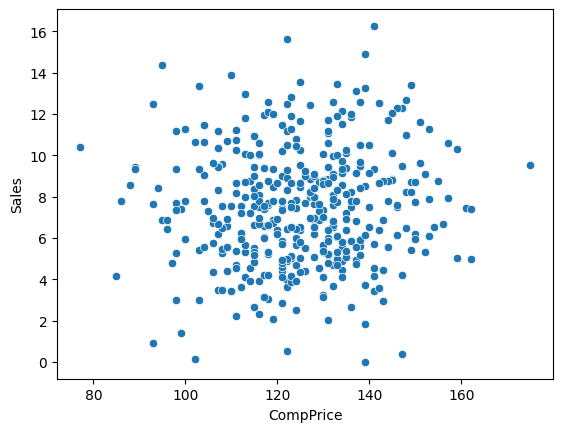

In [23]:
var = 'CompPrice'

sns.scatterplot(x=var, y = target, data = df)
plt.show()

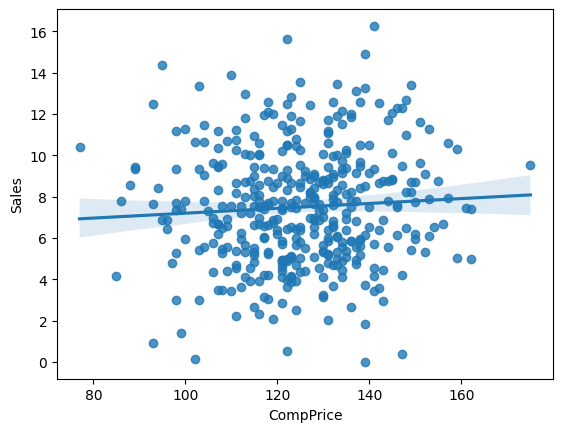

In [24]:
sns.regplot(x=var, y = target, data = df)
plt.show()

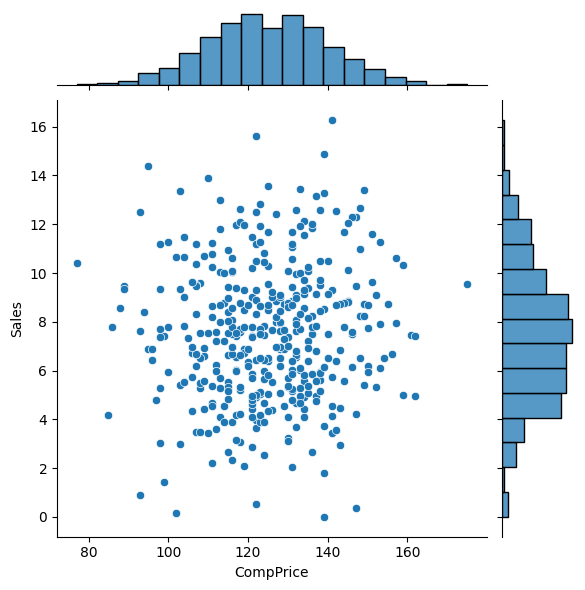

In [25]:
sns.jointplot(x=var, y = target, data = df)
plt.show()

2) 수치화 : 상관분석

In [26]:
result = spst.pearsonr(df[var], df[target])
print(f'상관계수 : {result[0]}, p-value : {result[1]}')

상관계수 : 0.06407872955062154, p-value : 0.20093982894184056


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- 가격 경쟁력 이라는 변수를 새로 만들어 봅시다.

In [27]:
df['Price_diff'] = df['CompPrice'] - df['Price']
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Urban,US,Price_diff
0,9.50,138,73,11,276,120,Bad,42,Yes,Yes,18
1,11.22,111,48,16,260,83,Good,65,Yes,Yes,28
2,10.06,113,35,10,269,80,Medium,59,Yes,Yes,33
3,7.40,117,100,4,466,97,Medium,55,Yes,Yes,20
4,4.15,141,64,3,340,128,Bad,38,Yes,No,13


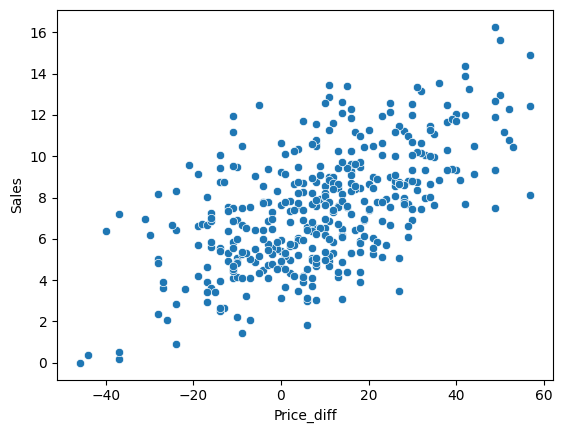

In [28]:
var ='Price_diff'
sns.scatterplot(x=var, y = target, data = df)
plt.show()

In [29]:
result = spst.pearsonr(df[var], df[target])
print(f'상관계수 : {result[0]}, p-value : {result[1]}')

상관계수 : 0.5979217124533923, p-value : 3.87712064178883e-40


- 경쟁사 가격 자체는 의미가 없지만, 가격경쟁력으로 비교할때는 비교적 강한 상관관계를 보인다.

### 2.6. Income -> Sales

1) 시각화 : scatter(regplot), jointplot

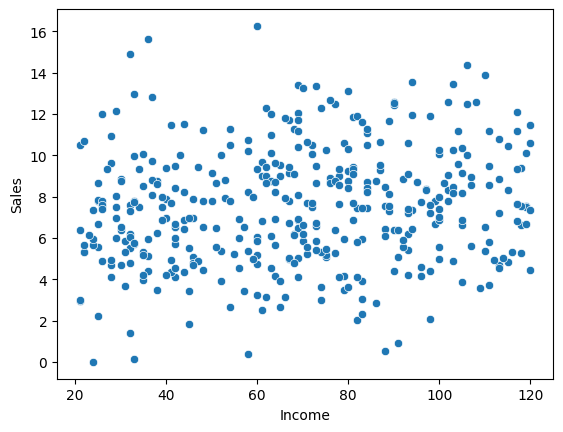

In [30]:
var = 'Income'

sns.scatterplot(x=var, y = target, data = df)
plt.show()

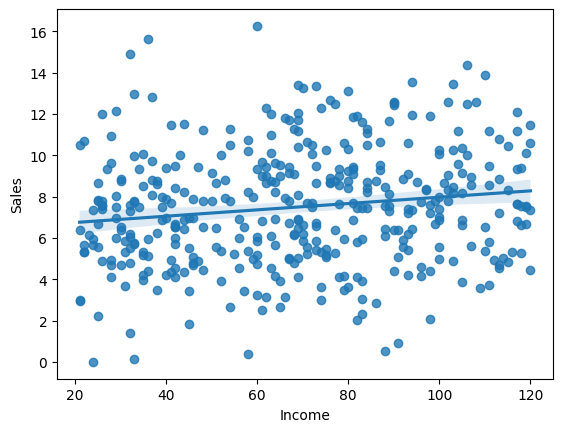

In [31]:
sns.regplot(x=var, y = target, data = df)
plt.show()

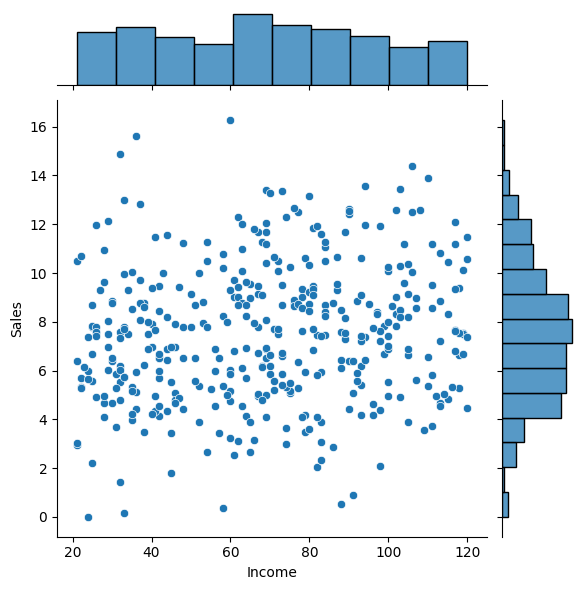

In [32]:
sns.jointplot(x=var, y = target, data = df)
plt.show()

2) 수치화 : 상관분석

In [33]:
result = spst.pearsonr(df[var], df[target])
print(f'상관계수 : {result[0]}, p-value : {result[1]}')

상관계수 : 0.15195097946754427, p-value : 0.002309670453951773


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- 관련이 없지는 않지만 약한 관계



---



# 3.범주형 X --> Y

* 모든 범자형 X에 대해서 Y와 비교하여 차트를 그리고 수치화 하시오.

① 시각화 : 평균비교 barplot  
② 수치화 : t-test, anova

### 3.1. ShelveLoc-> Sales

1) 시각화 : 평균비교 barplot

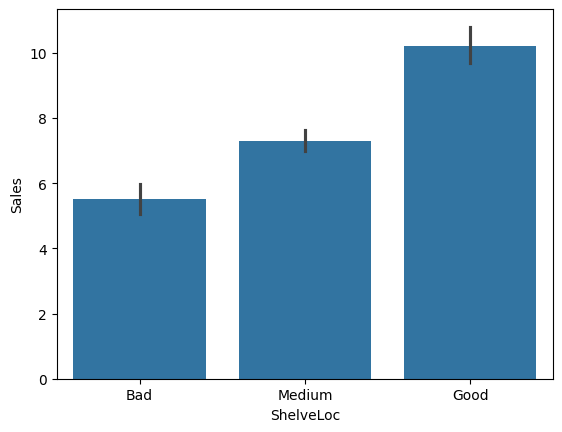

In [34]:
var='ShelveLoc'

sns.barplot(x=var, y= target, data=df, order = ['Bad', 'Medium', 'Good'])  # order: 원하는 순서대로
plt.show()

2) 수치화 : t-test, anova

In [ ]:
d_b = df.loc[df[var]=='Bad', target]
d_m = df.loc[df[var]=='Medium', target]
d_g = df.loc[df[var]=='Good', target]

spst.f_oneway(d_b,d_m,d_g)

# 귀무가설 (H₀): 모든 그룹의 평균은 같다.
# 대립가설 (H₁): 적어도 하나의 그룹 평균은 다르다.


F_onewayResult(statistic=np.float64(92.22990509910349), pvalue=np.float64(1.2669360901590919e-33))

3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- 분산비, 집단간의 분산이 크다. 전체 평균과 개별 평균의 차이가 크다.
- 세 그룹간 평균의 차이가 있다.

### 3.2. Urban -> Sales

1) 시각화 : 평균비교 barplot

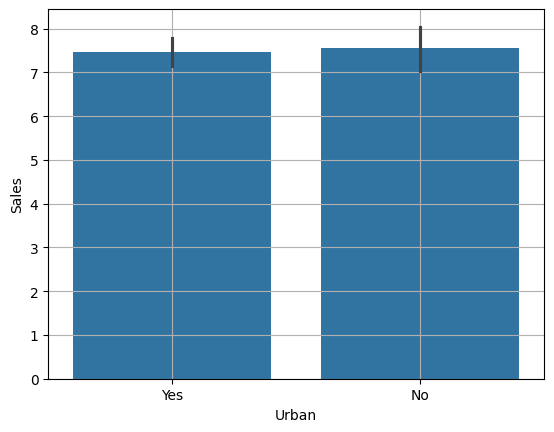

In [36]:
var='Urban'

sns.barplot(x=var, y= target, data=df)
plt.grid()
plt.show()

2) 수치화 : t-test, anova

In [37]:
u_y = df.loc[df[var]=='Yes', target]
u_n = df.loc[df[var]=='No', target]

print(spst.ttest_ind(u_y,u_n))

TtestResult(statistic=np.float64(-0.30765346670661126), pvalue=np.float64(0.7585069603942773), df=np.float64(398.0))


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- 두 그룹간 평균의 차이가 없다
- 도심 여부와 판매량은 관련(차이)가 없다.

### 3.3. US-> Sales

1) 시각화 : 평균비교 barplot

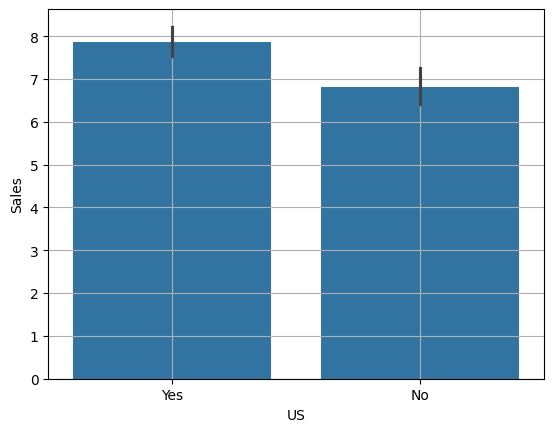

In [38]:
var='US'

sns.barplot(x=var, y= target, data=df)
plt.grid()
plt.show()

2) 수치화 : t-test, anova

In [39]:
us_y = df.loc[df[var]=='Yes', target]
us_n = df.loc[df[var]=='No', target]

print(spst.ttest_ind(us_y,us_n))

TtestResult(statistic=np.float64(3.589738747802499), pvalue=np.float64(0.00037233958701471544), df=np.float64(398.0))


3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- 두 그룹간 평균에 차이가 있다

# 4.관계 정리하기

① 강한관계

In [ ]:
# shelveLoc, Price_diff

② 중간관계

In [ ]:
# Price, US, Advertising

③ 관계없음

In [ ]:
# Pop, Age(약한 관계), Income(약한 관계), Urban